In [26]:
import pandas as pd

df_trades = pd.read_csv("historical_data.csv")
df_sentiment = pd.read_csv("fear_greed_index.csv")

In [27]:
df_trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [28]:
df_trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [29]:
df_sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [30]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [31]:
df_trades['Timestamp IST'] = pd.to_datetime(
    df_trades['Timestamp IST'].str.strip(),
    format='%d-%m-%Y %H:%M'
)

df_trades['date'] = df_trades['Timestamp IST'].dt.date

In [32]:
df_trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [33]:
df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date

In [34]:
df_sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [35]:
df_trades.columns = df_trades.columns.str.strip().str.lower().str.replace(' ', '_')
df_sentiment.columns = df_sentiment.columns.str.strip().str.lower().str.replace(' ', '_')

In [39]:
df_trades['side'] = df_trades['side'].str.lower()
df_trades['direction'] = df_trades['direction'].str.lower()

In [41]:
df_trades['is_profit'] = df_trades['closed_pnl'] > 0

In [48]:
df_trades.head(5)

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,is_profit,is_long
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-12-02 22:50:00,0.000000,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,False,1
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-12-02 22:50:00,986.524596,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,False,1
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-12-02 22:50:00,1002.518996,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,False,1
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-12-02 22:50:00,1146.558564,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,False,1
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-12-02 22:50:00,1289.488521,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,False,1


In [45]:
df_trades['is_long'] = df_trades['side'].apply(lambda x: 1 if x == 'buy' else 0)

In [49]:
df_daily = df_trades.groupby(['account', 'date']).agg({
    'closed_pnl': 'sum',
    'size_usd': 'sum',
    'execution_price': 'mean',
    'is_profit': 'mean',
    'is_long': 'mean',
    'fee': 'sum'
}).reset_index()

In [64]:
df_daily = df_daily.rename(columns={
    'closed_pnl': 'daily_pnl',
    'size_usd': 'total_volume',
    'execution_price': 'avg_price',
    'is_profit': 'win_rate',
    'is_long': 'long_ratio',
    'fee': 'total_fees'
})

In [65]:
df_daily.head()

,account,date,daily_pnl,total_volume,avg_price,win_rate,long_ratio,total_fees
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,900880.13,3204.461017,0.000000,0.000000,167.796055
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,542413.18,653.365147,0.000000,0.000000,67.883615
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,949380.00,3164.600000,0.000000,0.000000,94.937983
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,338240.00,3382.400000,0.000000,1.000000,33.823995
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,465700.00,232.921111,0.444444,0.444444,104.622490


In [66]:
df_final = df_daily.merge(df_sentiment, on='date', how='left')

In [67]:
df_final.head()

,account,date,daily_pnl,total_volume,avg_price,win_rate,long_ratio,total_fees,timestamp,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,900880.13,3204.461017,0.000000,0.000000,167.796055,1.731303e+09,76.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,542413.18,653.365147,0.000000,0.000000,67.883615,1.731821e+09,90.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,949380.00,3164.600000,0.000000,0.000000,94.937983,1.731908e+09,83.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,338240.00,3382.400000,0.000000,1.000000,33.823995,1.732253e+09,94.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,465700.00,232.921111,0.444444,0.444444,104.622490,1.732599e+09,79.0,Extreme Greed


In [68]:
df_final.describe()

,daily_pnl,total_volume,avg_price,win_rate,long_ratio,total_fees,timestamp,value
count,2341.000000,2.341000e+03,2341.000000,2341.000000,2341.000000,2341.000000,2.340000e+03,2340.000000
mean,4398.530091,5.088370e+05,14509.967892,0.359926,0.489142,105.022521,1.734850e+09,54.852137
std,28415.938999,2.413745e+06,29558.424507,0.343601,0.364306,461.394026,1.039061e+07,20.619321
min,-358963.139984,0.000000e+00,0.000005,0.000000,0.000000,-4.847684,1.682919e+09,10.000000
25%,0.000000,1.576401e+04,5.744733,0.000000,0.142857,2.982829,1.732772e+09,34.000000
50%,207.983482,6.935739e+04,27.621429,0.318182,0.486486,13.705607,1.738042e+09,55.000000
75%,1842.839943,2.507812e+05,5998.727154,0.608000,0.833333,55.308675,1.742276e+09,74.000000
max,533974.662903,5.125045e+07,107109.750000,1.000000,1.000000,10554.753586,1.746077e+09,94.000000


In [69]:
df_final['classification'].value_counts()

classification
Greed            648
Fear             630
Extreme Greed    526
Neutral          376
Extreme Fear     160
Name: count, dtype: int64

<h1> First Insight </h1>

Traders have low win rates, skewed profits, and high fees →
This screams behavioral inefficiency + emotional trading

<h1> Insight Extraction </h1>

How does sentiment affect trader performance and behavior?

In [70]:
sentiment_pnl = df_final.groupby('classification')['daily_pnl'].mean().sort_values()
print(sentiment_pnl)

classification
Greed            3318.100730
Neutral          3438.618818
Extreme Fear     4619.439053
Extreme Greed    5161.922644
Fear             5328.818161
Name: daily_pnl, dtype: float64


In [71]:
sentiment_winrate = df_final.groupby('classification')['win_rate'].mean()
print(sentiment_winrate)

classification
Extreme Fear     0.329659
Extreme Greed    0.386387
Fear             0.364033
Greed            0.343559
Neutral          0.355414
Name: win_rate, dtype: float64


This tells:

Where traders make money,
Where they lose

In [72]:
sentiment_volume = df_final.groupby('classification')['total_volume'].mean()
sentiment_fees = df_final.groupby('classification')['total_fees'].mean()

print(sentiment_volume)
print(sentiment_fees)

classification
Extreme Fear     715526.634000
Extreme Greed    236625.788156
Fear             767182.206016
Greed            445343.356049
Neutral          479367.189043
Name: total_volume, dtype: float64
classification
Extreme Fear     149.303962
Extreme Greed     51.389098
Fear             146.757061
Greed             97.374525
Neutral          104.718799
Name: total_fees, dtype: float64


This shows:

Are traders more active in Greed?
Do they overtrade?

In [73]:
sentiment_long = df_final.groupby('classification')['long_ratio'].mean()
print(sentiment_long)

classification
Extreme Fear     0.531533
Extreme Greed    0.473116
Fear             0.518967
Greed            0.471594
Neutral          0.472431
Name: long_ratio, dtype: float64


This reveals:

Are traders overly bullish in Greed?
Do they panic in Fear?

In [75]:
extreme = df_final[df_final['classification'].isin(['Extreme Fear', 'Extreme Greed'])]

extreme.groupby('classification')[['daily_pnl', 'win_rate', 'total_volume']].mean()

,daily_pnl,win_rate,total_volume
classification,,,
Extreme Fear,4619.439053,0.329659,715526.634000
Extreme Greed,5161.922644,0.386387,236625.788156


This is where:

Emotional trading peaks
Big losses usually happen

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

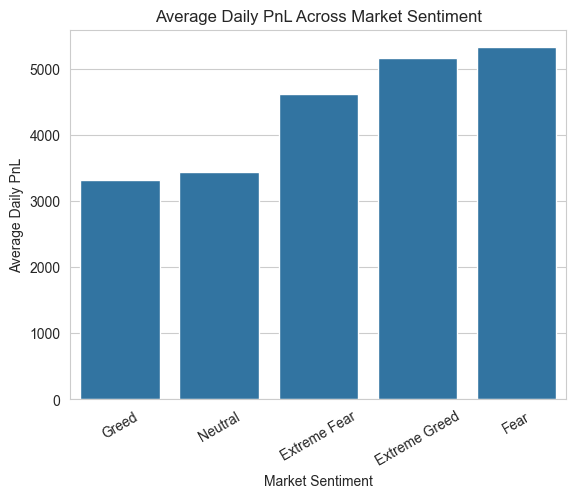

In [79]:
plt.figure()
sns.barplot(x=sentiment_pnl.index, y=sentiment_pnl.values)

plt.title("Average Daily PnL Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")

plt.xticks(rotation=30)
plt.show()

Profitability peaks during Fear regimes, indicating volatility-driven gains rather than stable performance.

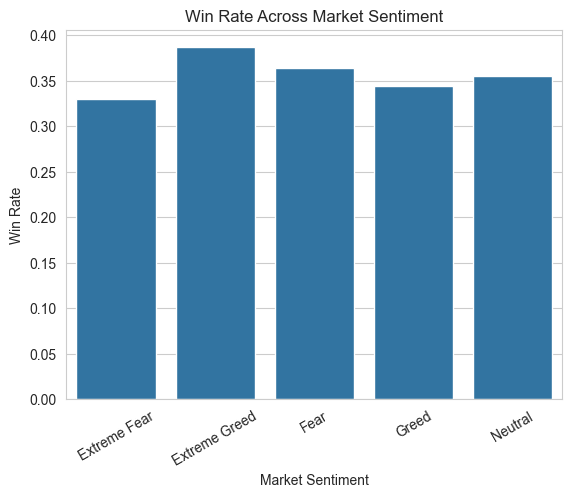

In [80]:
plt.figure()
sns.barplot(x=sentiment_winrate.index, y=sentiment_winrate.values)

plt.title("Win Rate Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.xticks(rotation=30)
plt.show()

Win rates are lowest during Extreme Fear, highlighting poor trade accuracy during volatile conditions.

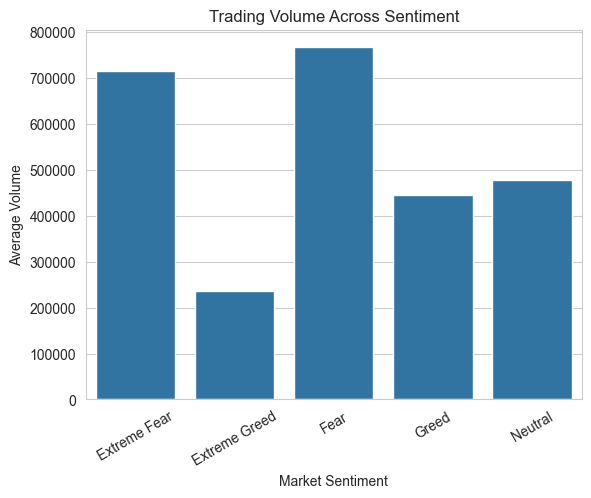

In [81]:
plt.figure()
sns.barplot(x=sentiment_volume.index, y=sentiment_volume.values)

plt.title("Trading Volume Across Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Volume")

plt.xticks(rotation=30)
plt.show()

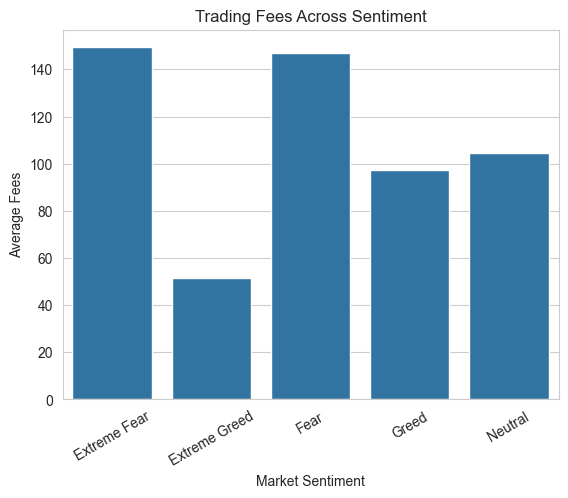

In [82]:
plt.figure()
sns.barplot(x=sentiment_fees.index, y=sentiment_fees.values)

plt.title("Trading Fees Across Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Fees")

plt.xticks(rotation=30)
plt.show()

Trading activity and fees spike during Fear, suggesting panic-driven overtrading.

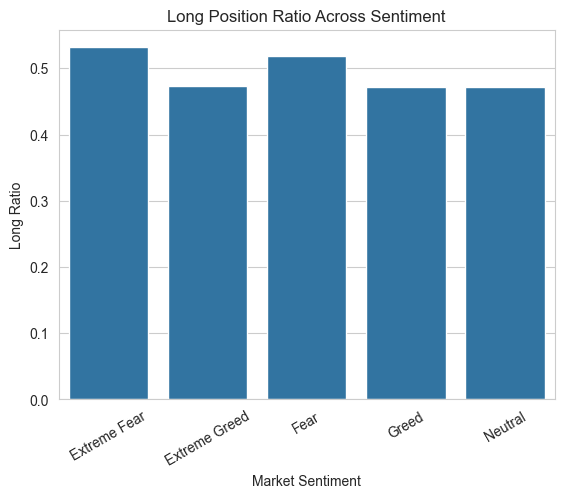

In [84]:
plt.figure()
sns.barplot(x=sentiment_long.index, y=sentiment_long.values)

plt.title("Long Position Ratio Across Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Long Ratio")

plt.xticks(rotation=30)
plt.show()

Traders increase long exposure during Fear, attempting to buy dips despite low success rates.

In [85]:
top_traders = df_final.groupby('account')['daily_pnl'].sum().sort_values(ascending=False).head(20)
top_accounts = top_traders.index

df_top = df_final[df_final['account'].isin(top_accounts)]
df_avg = df_final.copy()

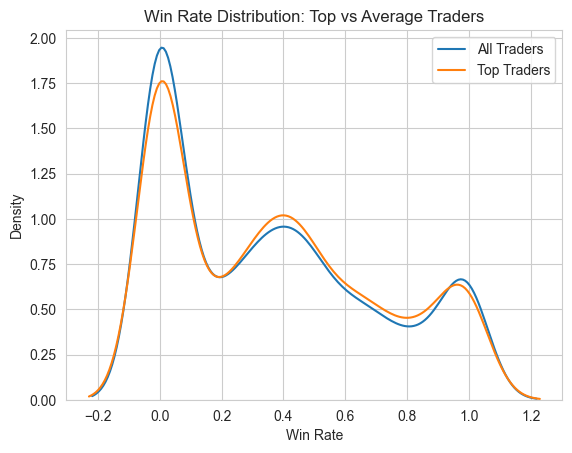

In [86]:
plt.figure()

sns.kdeplot(df_avg['win_rate'], label='All Traders')
sns.kdeplot(df_top['win_rate'], label='Top Traders')

plt.title("Win Rate Distribution: Top vs Average Traders")
plt.xlabel("Win Rate")
plt.legend()

plt.show()

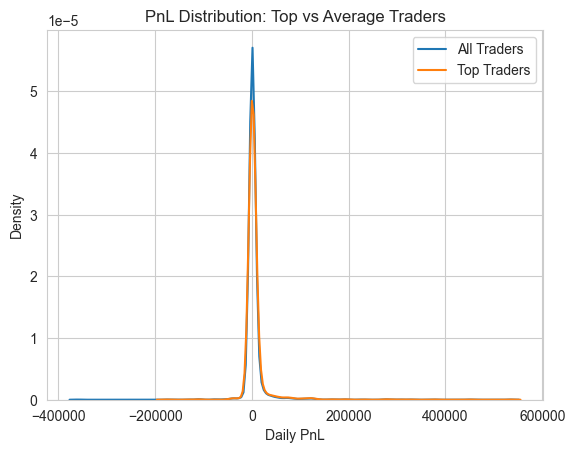

In [87]:
plt.figure()

sns.kdeplot(df_avg['daily_pnl'], label='All Traders')
sns.kdeplot(df_top['daily_pnl'], label='Top Traders')

plt.title("PnL Distribution: Top vs Average Traders")
plt.xlabel("Daily PnL")
plt.legend()

plt.show()

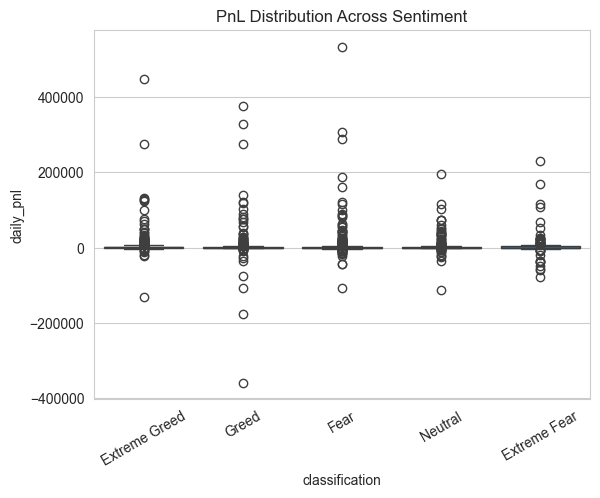

In [88]:
plt.figure()
sns.boxplot(x='classification', y='daily_pnl', data=df_final)

plt.title("PnL Distribution Across Sentiment")
plt.xticks(rotation=30)

plt.show()

Extreme outliers are more frequent during Fear regimes, confirming volatility-driven profits.